# Analysis of simulated trajectorories

In [2]:
cd ~/work/tutorials/sources/OpenDrift/openberg_custom_juliette 

/home/jovyan/work/tutorials/sources/OpenDrift/openberg_custom_juliette


In [3]:
# import pandas as pd
# import xarray as xr
# import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import glob
from src.utils import *
from src.utils2 import *

In [4]:
# Read and subset tracker data
obs_3day = read_tracker('./input/Osker-X2.csv')['3D']
obs = read_tracker('./input/Osker-X2.csv')['full']

/home/jovyan/work/tutorials/sources/OpenDrift/openberg_custom_juliette/src/utils2.py:109: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
/home/jovyan/work/tutorials/sources/OpenDrift/openberg_custom_juliette/src/utils2.py:109: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])


In [5]:
# def colour_finder(sim_in,by='reader_'):
#     #pick colormap
#     cmap = plt.get_cmap('tab20')  # or 'viridis', 'plasma', etc.
#     colors = cmap(np.linspace(0, 1, 20))#20 colors
#     if by=='reader_x_sea_water_velocity': 
#         val = sim_in.reader_x_sea_water_velocity
#     return col_dict

In [6]:
# --- Which simulation data for plot? ---
file_contain_all = ['_',] #list of key words that should ALL be contained in file name, if none required, write '_'
file_contain_any = ['wind','era5']
# file_contain_any = ['topaz5','topaz6-lowres_topaz5','glophyanfc'] #list of key words that, from which at least one should be contained in file name, if none required, write '_'
file_notcontain = ['topaz4','nextsim','wa','topaz5','topaz6-lowres','glophyanfc','glorys','topaz6',] #list of keywords that should not be in filename
file_l = glob.glob("./results/*.nc")#['./results/juliette_topaz6_topaz4_windglophynrt.nc',]
file_l = [f for f in file_l if all(ff in f for ff in file_contain_all)] #filtering for required keywords
file_l = [f for f in file_l if any(ff in f for ff in file_contain_any)] #filtering for required keywords
file_l = [f for f in file_l if all(ff not in f for ff in file_notcontain)] #filtering for neglected keywords
file_l

['./results/juliette_windglophynrt.nc',
 './results/juliette_era5.nc',
 './results/juliette_windglophyre.nc']

In [7]:
# --- Open all simulation results in one dataset ---
with xr.open_mfdataset(
    file_l,
    combine="nested",
    concat_dim="run",
    parallel=True,
    engine="netcdf4",
    # chunks={'time': 10}
) as simall: 
    simall = simall.assign_coords(run=file_l)  # or any list of labels

0 ./results/juliette_windglophynrt.nc [0.12156863 0.46666667 0.70588235 1.        ]
1 ./results/juliette_era5.nc [1.         0.49803922 0.05490196 1.        ]
2 ./results/juliette_windglophyre.nc [0.17254902 0.62745098 0.17254902 1.        ]


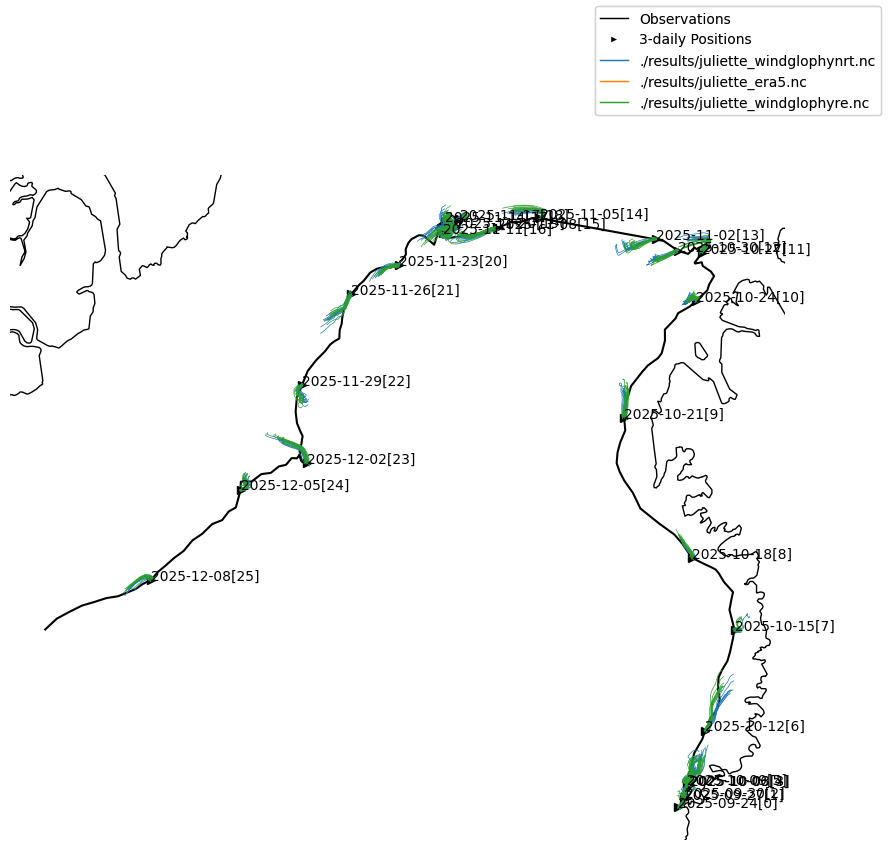

In [14]:
# Map plot comparing simulations with different input

#def
note = 'wind_only'
#by = inputdataidx
cmap = plt.get_cmap('tab20')  # or 'viridis', 'plasma', etc.
col = cmap(np.linspace(0, 1, 20))[::2]#20 colors
trajs = False #np.arange(60,70,10)

#Figure
fig,ax = plt.subplots(1,1,figsize=(10,10),subplot_kw={'projection':ccrs.NorthPolarStereo()})#central_longitude=20})
ax.coastlines(resolution='10m')
trans = ccrs.PlateCarree()
#ax.set_extent((-42.5, -11, 65, 78))

# plot obs
ax.plot(obs_3day['lon'],obs_3day['lat'],'>',transform=trans,color='k')
ax.plot(obs['lon'],obs['lat'],transform=trans,color='k',label='Observation')
# for d in range(obs_3day['time'].size):
for d in range(obs_3day.time.size):
    ax.text(obs_3day['lon'][d],obs_3day['lat'][d],obs_3day['time'][d].values.astype('datetime64[D]').astype(str)+'[%s]'%d,transform=trans,color='k')

# plot sim
for inputdataidx, inputdata in enumerate(simall.run.values):
    print(inputdataidx, inputdata, col[inputdataidx])
    for traj in simall.trajectory if trajs==False else trajs:
        ax.plot(simall.lon.sel(run=inputdata,trajectory=traj).dropna(dim="time"),simall.lat.sel(run=inputdata,trajectory=traj).dropna(dim="time"),
        color=col[inputdataidx],
                linewidth=0.5,
        transform=trans)
    # ax.plot(simall.lon.sel(run=inputdata),simall.lat.sel(run=inputdata),
    #         color=col[inputdataidx],linewidth=0.5,
    #         transform=trans)
    # dssim = xr.open_dataset(inputdata)
    # for traj in dssim.trajectory: #goes trhough trajectories with different coefficients, size, time and position #p.arange(0,dssim.trajectory[-1],10)
    #     ax.plot(dssim.lon[traj].dropna(dim="time"),dssim.lat[traj].dropna(dim="time"),
    #             color=col[inputdataidx],linewidth=0.5,
    #             transform=trans)
#legend
legend_elements = [Line2D([0], [0],linestyle='-', color='k', lw=1,label='Observations'),
                  Line2D([0], [0],linestyle='-', color='w',marker='>',markerfacecolor='k', lw=1,label='3-daily Positions')]
legend_elements = legend_elements+[Line2D([0], [0],linestyle='-', color=col[inputdataidx2], lw=1,label=inputdata2) for inputdataidx2,inputdata2 in enumerate(simall.run.values)]
leg = fig.legend(handles=legend_elements,)#fontsize=fs,ncol=len(legend_elements0+legend_elements2),                  columnspacing=0.6,labelspacing=0.3,loc='center',bbox_to_anchor=bbox_dict[kw][0])
plt.axis('off')
fig.add_artist(leg)
if note!=False: plt.savefig('./results/map_%s.png'%note,dpi=200,transparent=True,bbox_inches='tight')
plt.show()



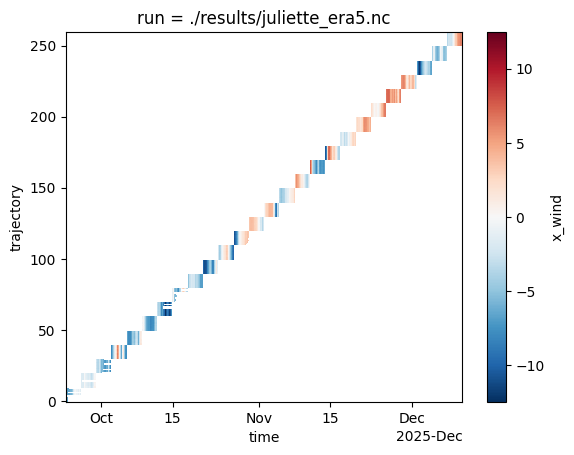

In [27]:
simall.x_wind.plot()

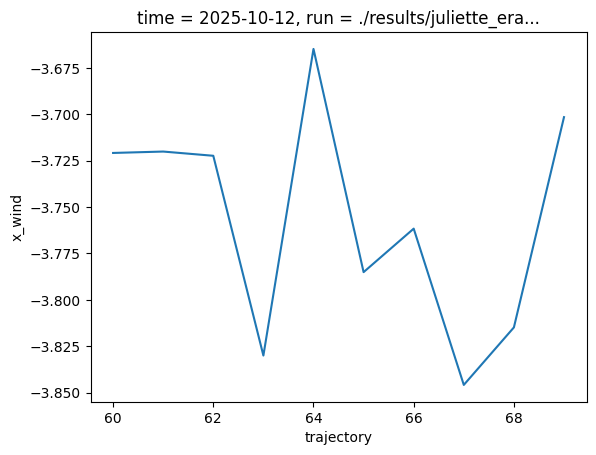

In [26]:
# --Check for variables from one "seeding round"
# simall.length[0,np.arange(60,70),:].dropna(dim='time').shape 

# --Check for variables at datetime
simall_t1 = simall.sel(time=datetime(2025,10,12,0), method="nearest") 

simall_t1_nan = simall_t1.dropna(
    dim="trajectory",
    # subset=["sea_surface_wave_from_direction"],
    subset=["length"],
    how="any" )
# print(simall_t1_nan.run) #which runs
#print (simall_t1_nan.trajectory) #which trajectory numbers
# simall_t1_nan.sea_surface_wave_from_direction.values
# simall_t1_nan.sea_surface_wave_significant_height.values
# simall_t1_nan.sea_surface_wave_stokes_drift_x_velocity.plot()
# simall_t1_nan.x_sea_water_velocity.values
simall_t1_nan.x_wind.plot()

# simall_t1_nan.draft.values#[:,0].values


In [ ]:
# --- open one result ---
sim = xr.open_dataset('./results/juliette_topaz5_arcmfcwam_windglophynrt.nc')
# np.sum(np.isnan(sim.x_sea_water_velocity))/sim.x_sea_water_velocity.size
# sim_t1 = sim.sel(time=datetime(2025,10,21,0), method="nearest") 
# sim_t1.sea_surface_wave_from_direction.plot()

In [ ]:
# #check on included processes:
# # sim = xr.open_dataset('./results/juliette_topaz5_windglophynrt.nc')
# for inputdataidx, inputdata in enumerate(file_l):
#     dssim = xr.open_dataset(inputdata)
#     print(inputdataidx, inputdata, sim.attrs['config_drift:wave_rad'])


In [ ]:
# dssim.sea_surface_wave_significant_height.plot()


In [ ]:
# dssim



In [ ]:
# era = xr.open_dataset('./input/era5_juliette.nc')

In [ ]:
# era
